## Notebook to test .py implementation workflow

In [12]:
import numpy as np

from src.utils.seed import set_seed
from src.utils.plotting import plot_learning_curve
from src.utils.env import make_env
from src.utils.stats import compute_stats
from experiments.cartpole import run_experiments
from src.algorithms.dqn import DQNAgent

In [13]:
# -----------------------
# Random baseline agent
# (placeholder for DQN/PPO/etc.)
# -----------------------
class RandomAgent:
    """
    A simple agent that takes random actions in the environment.
    This is a baseline for testing our environment and code setup.
    """
    def __init__(self, action_space):
        self.action_space = action_space

    def act(self, state):
        return self.action_space.sample()
    def set_eval_mode(self, mode: bool):
        pass

In [ ]:
rnd_logs = run_experiments(
    agent_fn=lambda action_space, state_dim: RandomAgent(action_space),
    seeds=[0, 1, 2],
    n_episodes=100,
    eval_interval=10
)

dqn_logs = run_experiments(
    agent_fn=lambda action_space, state_dim: DQNAgent(
        action_space=action_space,
        state_dim=state_dim,
        gamma=0.99,
        batch_size=64,
        eps=1.0,
        eps_min=0.05,
        eps_decay=0.999,
        target_update_freq=500,
        buffer_capacity=20000,
        lr=1e-3
    ),
    seeds=[0, 1, 2],
    n_episodes=500,
    eval_interval=30
)

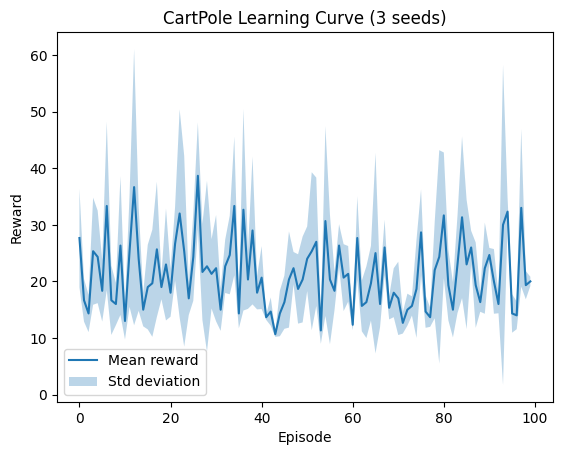

In [6]:
rewards_rnd = [logger.episode_rewards for logger in rnd_logs]
mean_rewards_rnd, std_rewards_rnd = compute_stats(rewards_rnd)
episodes = np.arange(len(mean_rewards_rnd))

plot_learning_curve(episodes, mean_rewards_rnd, std_rewards_rnd)

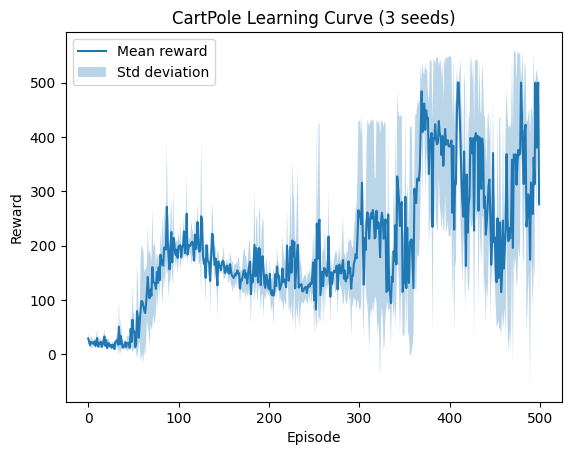

In [7]:
rewards_dqn = [logger.episode_rewards for logger in dqn_logs] 
mean_rewards_dqn, std_rewards_dqn = compute_stats(rewards_dqn)
episodes = np.arange(len(mean_rewards_dqn))

plot_learning_curve(episodes, mean_rewards_dqn, std_rewards_dqn)

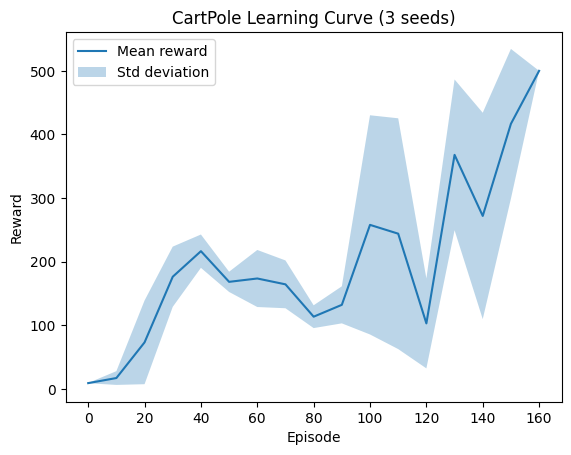

In [8]:
# plot evaluation rewards
eval_rewards_dqn = [logger.eval_rewards for logger in dqn_logs]
mean_eval_rewards_dqn, std_eval_rewards_dqn = compute_stats(eval_rewards_dqn)
eval_episodes = np.arange(len(mean_eval_rewards_dqn)) * 10
plot_learning_curve(eval_episodes, mean_eval_rewards_dqn, std_eval_rewards_dqn)

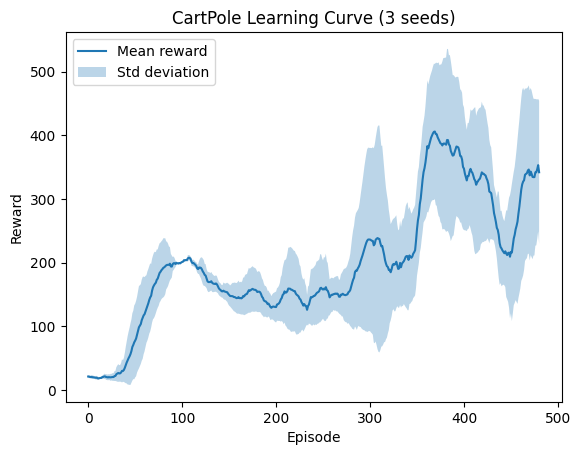

In [9]:
# plot episode reward (for dqn) with moving average

mva_ep_rewards_dqn = [logger.moving_average(window=20) for logger in dqn_logs]
mean_ep_rewards_dqn, std_ep_rewards_dqn = compute_stats(mva_ep_rewards_dqn)
episodes = np.arange(len(mean_ep_rewards_dqn))
plot_learning_curve(episodes, mean_ep_rewards_dqn, std_ep_rewards_dqn)

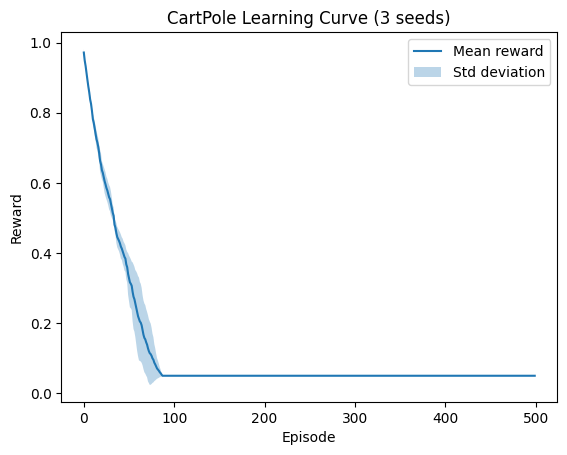

In [10]:
# plot epsilon decay for dqn
epsilons_dqn = [logger.epsilons for logger in dqn_logs]
mean_epsilons_dqn, std_epsilons_dqn = compute_stats(epsilons_dqn)
episodes = np.arange(len(mean_epsilons_dqn))
plot_learning_curve(episodes, mean_epsilons_dqn, std_epsilons_dqn)

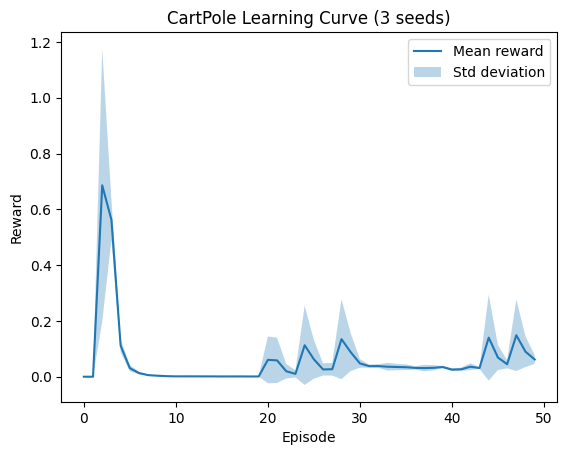

In [11]:
losses_dqn = np.array([logger.losses for logger in dqn_logs])
min_len = min(len(l) for l in losses_dqn)
losses_dqn = np.array([l[:min_len] for l in losses_dqn])

losses_mean = losses_dqn.mean(axis=0)
losses_std = losses_dqn.std(axis=0)

episodes = np.arange(min_len)

plot_learning_curve(episodes[:50], losses_mean[:50], losses_std[:50])